# Word-Level Lyrics Generator Using LSTM

### Import Configurations

In [ ]:
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split
from torch import accelerator
from torch import nn

device = accelerator.current_accelerator() if accelerator.is_available() else 'cpu'
print(f"Using {device} device")

Using cuda device


### Eminem Songs Dataset

In [ ]:
song_data = pd.read_csv(r'data/Eminem.csv', index_col=0)
song_data.head()

,Artist,Title,Album,Year,Date,Lyric
0,Eminem,Rap God,The Marshall Mathers LP2 (Deluxe),2013.0,2013-10-15,look i was gonna go easy on you not to hurt yo...
1,Eminem,Killshot,NaN,2018.0,2018-09-14,you sound like a bitch bitch shut the fuck up ...
2,Eminem,Godzilla,Music to Be Murdered By,2020.0,2020-01-17,ugh you're a monster eminem i can swallow a ...
3,Eminem,Lose Yourself,The Singles,2002.0,2002-10-28,look if you had one shot or one opportunity to...
4,Eminem,The Monster,The Marshall Mathers LP2 (Deluxe),2013.0,2013-10-29,rihanna i'm friends with the monster that's un...


In [ ]:
print(song_data.shape)

(521, 6)


### Data Inspection

In [ ]:
print(song_data.info())
print(song_data.isna().sum())
print(f'Number of duplicated lyrics: {song_data['Lyric'].duplicated().sum()}')

<class 'pandas.core.frame.DataFrame'>
Index: 521 entries, 0 to 520
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Artist  521 non-null    object 
 1   Title   521 non-null    object 
 2   Album   353 non-null    object 
 3   Year    396 non-null    float64
 4   Date    396 non-null    object 
 5   Lyric   521 non-null    object 
dtypes: float64(1), object(5)
memory usage: 44.7+ KB
None
Artist      0
Title       0
Album     168
Year      125
Date      125
Lyric       0
dtype: int64
Number of duplicated lyrics: 6


In [ ]:
song_data['Lyric'] = song_data['Lyric'].drop_duplicates()

In [ ]:
lyrics_list = []
for lyric in song_data['Lyric']:
  if isinstance(lyric, str):
    lyrics_list.append(lyric)

print(len(lyrics_list))

515


In [ ]:
lyrics_list[:2]

["look i was gonna go easy on you not to hurt your feelings but i'm only going to get this one chance six minutes six minutes something's wrong i can feel it six minutes slim shady you're on just a feeling i've got like something's about to happen but i don't know what\xa0 if that means what i think it means we're in trouble big trouble\xa0 and if he is as bananas as you say i'm not taking any chances you are just what the doc ordered   i'm beginnin' to feel like a rap god rap god all my people from the front to the back nod back nod now who thinks their arms are long enough to slap box slap box they said i rap like a robot so call me rapbot   but for me to rap like a computer it must be in my genes i got a laptop in my back pocket my pen'll go off when i halfcock it got a fat knot from that rap profit made a livin' and a killin' off it ever since bill clinton was still in office with monica lewinsky feelin' on his nutsack i'm an mc still as honest but as rude and as indecent as all he

### Vocabulary Creation

In [ ]:
all_words = []

for lyric in lyrics_list:
  all_words.extend(lyric.split())

min_freq = 5
word_counts = Counter(all_words)
vocab = [
    word
    for word, count in word_counts.items()
    if count >= min_freq
]

In [ ]:
vocab

['look',
 'i',
 'was',
 'gonna',
 'go',
 'easy',
 'on',
 'you',
 'not',
 'to',
 'hurt',
 'your',
 'feelings',
 'but',
 "i'm",
 'only',
 'going',
 'get',
 'this',
 'one',
 'chance',
 'six',
 'minutes',
 "something's",
 'wrong',
 'can',
 'feel',
 'it',
 'slim',
 'shady',
 "you're",
 'just',
 'a',
 'feeling',
 "i've",
 'got',
 'like',
 'about',
 'happen',
 "don't",
 'know',
 'what',
 'if',
 'that',
 'means',
 'think',
 "we're",
 'in',
 'trouble',
 'big',
 'and',
 'he',
 'is',
 'as',
 'bananas',
 'say',
 'taking',
 'any',
 'chances',
 'are',
 'the',
 'doc',
 'ordered',
 "beginnin'",
 'rap',
 'god',
 'all',
 'my',
 'people',
 'from',
 'front',
 'back',
 'nod',
 'now',
 'who',
 'thinks',
 'their',
 'arms',
 'long',
 'enough',
 'slap',
 'box',
 'they',
 'said',
 'so',
 'call',
 'me',
 'for',
 'computer',
 'must',
 'be',
 'pocket',
 'off',
 'when',
 'fat',
 'knot',
 'profit',
 'made',
 "livin'",
 "killin'",
 'ever',
 'since',
 'bill',
 'clinton',
 'still',
 'office',
 'with',
 'monica',
 "feel

### Word to Index Mapping

In [ ]:
word2idx = {'<PAD>' : 0, '<UNK>' : 1}
idx2word = {0 : '<PAD>', 1 : '<UNK>'}

for idx, word in enumerate(vocab, start=2):
      word2idx[word] = idx
      idx2word[idx] = word

print(word2idx)
print(idx2word)

{'<PAD>': 0, '<UNK>': 1, 'look': 2, 'i': 3, 'was': 4, 'gonna': 5, 'go': 6, 'easy': 7, 'on': 8, 'you': 9, 'not': 10, 'to': 11, 'hurt': 12, 'your': 13, 'feelings': 14, 'but': 15, "i'm": 16, 'only': 17, 'going': 18, 'get': 19, 'this': 20, 'one': 21, 'chance': 22, 'six': 23, 'minutes': 24, "something's": 25, 'wrong': 26, 'can': 27, 'feel': 28, 'it': 29, 'slim': 30, 'shady': 31, "you're": 32, 'just': 33, 'a': 34, 'feeling': 35, "i've": 36, 'got': 37, 'like': 38, 'about': 39, 'happen': 40, "don't": 41, 'know': 42, 'what': 43, 'if': 44, 'that': 45, 'means': 46, 'think': 47, "we're": 48, 'in': 49, 'trouble': 50, 'big': 51, 'and': 52, 'he': 53, 'is': 54, 'as': 55, 'bananas': 56, 'say': 57, 'taking': 58, 'any': 59, 'chances': 60, 'are': 61, 'the': 62, 'doc': 63, 'ordered': 64, "beginnin'": 65, 'rap': 66, 'god': 67, 'all': 68, 'my': 69, 'people': 70, 'from': 71, 'front': 72, 'back': 73, 'nod': 74, 'now': 75, 'who': 76, 'thinks': 77, 'their': 78, 'arms': 79, 'long': 80, 'enough': 81, 'slap': 82, '

### Encoding Lyrics

In [ ]:
encoded_list = []

for lyric in lyrics_list:
  word_list = [word2idx.get(word, word2idx['<UNK>']) for word in lyric.split()]
  encoded_list.append(word_list)

print(encoded_list[:2])

[[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 11, 19, 20, 21, 22, 23, 24, 23, 24, 25, 26, 3, 27, 28, 29, 23, 24, 30, 31, 32, 8, 33, 34, 35, 36, 37, 38, 25, 39, 11, 40, 15, 3, 41, 42, 43, 44, 45, 46, 43, 3, 47, 29, 46, 48, 49, 50, 51, 50, 52, 44, 53, 54, 55, 56, 55, 9, 57, 16, 10, 58, 59, 60, 9, 61, 33, 43, 62, 63, 64, 16, 65, 11, 28, 38, 34, 66, 67, 66, 67, 68, 69, 70, 71, 62, 72, 11, 62, 73, 74, 73, 74, 75, 76, 77, 78, 79, 61, 80, 81, 11, 82, 83, 82, 83, 84, 85, 3, 66, 38, 34, 1, 86, 87, 88, 1, 15, 89, 88, 11, 66, 38, 34, 90, 29, 91, 92, 49, 69, 1, 3, 37, 34, 1, 49, 69, 73, 93, 69, 1, 6, 94, 95, 3, 1, 29, 37, 34, 96, 97, 71, 45, 66, 98, 99, 34, 100, 52, 34, 101, 94, 29, 102, 103, 104, 105, 4, 106, 49, 107, 108, 109, 1, 110, 8, 111, 1, 16, 112, 113, 106, 55, 114, 15, 55, 115, 52, 55, 1, 55, 68, 116, 117, 1, 118, 119, 68, 108, 20, 1, 1, 120, 9, 41, 121, 122, 19, 123, 34, 124, 125, 108, 20, 1, 126, 127, 34, 128, 49, 62, 73, 129, 62, 1, 130, 66, 131, 1, 1, 52, 132, 62, 133

### UNK Token Analysis

In [ ]:
unk_count = 0
total_tokens = 0

for song in encoded_list:
    total_tokens += len(song)
    unk_count += song.count(1)

print("UNK Count:", unk_count)
print("UNK %:", unk_count / total_tokens * 100)

UNK Count: 26430
UNK %: 7.607550558692987


### Sequence Length Demonstration

In [ ]:
SEQ_LEN = 20

for lyric in encoded_list[:5]:
  curr_words = []
  for word, next_word in zip(lyric, lyric[1:]):
    curr_words.append(word)
    print(f"{curr_words} -> {next_word}")
    if len(curr_words) > SEQ_LEN:
      break
  print()

[2] -> 3
[2, 3] -> 4
[2, 3, 4] -> 5
[2, 3, 4, 5] -> 6
[2, 3, 4, 5, 6] -> 7
[2, 3, 4, 5, 6, 7] -> 8
[2, 3, 4, 5, 6, 7, 8] -> 9
[2, 3, 4, 5, 6, 7, 8, 9] -> 10
[2, 3, 4, 5, 6, 7, 8, 9, 10] -> 11
[2, 3, 4, 5, 6, 7, 8, 9, 10, 11] -> 12
[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12] -> 13
[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13] -> 14
[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14] -> 15
[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15] -> 16
[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16] -> 17
[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17] -> 18
[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18] -> 11
[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 11] -> 19
[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 11, 19] -> 20
[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 11, 19, 20] -> 21
[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 11, 19, 20, 21] -> 22

[9] -> 477
[9, 477] -> 38
[9, 477, 38] -> 34
[9, 477, 38, 34] -> 478
[9, 47

### Input and Target Generation

In [ ]:
SEQ_LEN = 20

inputs = []
targets = []

for song in encoded_list:

    if len(song) <= SEQ_LEN:
        continue

    for i in range(len(song) - SEQ_LEN):

        inputs.append(
            song[i:i+SEQ_LEN]
        )

        targets.append(
            song[i+SEQ_LEN]
        )

### Tensor Conversion

In [ ]:
X = torch.tensor(inputs, dtype=torch.long)
y = torch.tensor(targets, dtype=torch.long)

print(f"Shape of X tensor: {X.shape}\nShape of y tensor: {y.shape}")

Shape of X tensor: torch.Size([337270, 20])
Shape of y tensor: torch.Size([337270])


In [ ]:
X[:5]

tensor([[ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 11,
         19, 20],
        [ 3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 11, 19,
         20, 21],
        [ 4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 11, 19, 20,
         21, 22],
        [ 5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 11, 19, 20, 21,
         22, 23],
        [ 6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 11, 19, 20, 21, 22,
         23, 24]])

### Custom Dataset Class

In [ ]:
class LyricDataset(Dataset):
  def __init__(self, X, y):
    self.X = X
    self.y = y

  def __len__(self):
    return len(self.X)

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]

dataset = LyricDataset(X, y)
print(f'Dataset size: {len(dataset)}')

input_seq, target = dataset[5]
print(f"Sample data: input = {input_seq}, target = {target}")

Dataset size: 337270
Sample data: input = tensor([ 7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 11, 19, 20, 21, 22, 23,
        24, 23]), target = 24


### DataLoaders and Train/Test Split

In [ ]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_data, test_data = random_split(dataset=dataset, lengths=[train_size, test_size])

train_loader = DataLoader(dataset=train_data, batch_size=128, shuffle=True)
test_loader = DataLoader(dataset=test_data, batch_size=128, shuffle=False)

x_batch, y_batch = next(iter(train_loader))
print(f'Shape of x batch: {x_batch.shape}')
print(f'Shape of y batch: {y_batch.shape}')

Shape of x batch: torch.Size([128, 20])
Shape of y batch: torch.Size([128])


### LSTM Model Architecture

In [ ]:
word_size = len(word2idx)

class LyricLSTM(nn.Module):
  def __init__(self, word_size, embed_dim, hidden_dim, num_layers=1, dropout_prob = 0.5):
    super().__init__()
    self.embedding = nn.Embedding(word_size, embed_dim)
    self.lstm = nn.LSTM(
        input_size=embed_dim,
        hidden_size=hidden_dim,
        num_layers=num_layers,
        batch_first=True
    )
    self.dropout = nn.Dropout(dropout_prob)
    self.ffn = nn.Linear(in_features=hidden_dim, out_features=word_size)

  def forward(self, x):
    x = self.embedding(x)
    out, _ = self.lstm(x)
    out = out[:, -1, :]
    out = self.dropout(out)
    out = self.ffn(out)
    return out

model = LyricLSTM(word_size, 128, 512, num_layers=3, dropout_prob=0.2).to(device)
print(f"Model summary: {model}")

Model summary: LyricLSTM(
  (embedding): Embedding(4981, 128)
  (lstm): LSTM(128, 512, num_layers=3, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (ffn): Linear(in_features=512, out_features=4981, bias=True)
)


### Model Training & Validation

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=1e-3)

train_loss_history = []
val_loss_history = []
epoch_acc = 0.0

# Early Stopping Parameters
patience = 3 # Number of epochs to wait if no improvement in validation loss
min_delta = 0.0001 # Minimum change in the monitored quantity to qualify as an improvement
best_val_loss = float('inf')
epochs_no_improve = 0
early_stop_triggered = False

for epoch in range(15):
  # ==============================================================
  # Training Section
  # ==============================================================
  model.train()
  total_train_loss = 0.0
  current_epoch_train_loss = 0.0
  for x_batch, y_batch in train_loader:
    x_batch, y_batch = x_batch.to(device), y_batch.to(device)
    preds = model(x_batch)
    train_loss = criterion(preds, y_batch)
    optimizer.zero_grad()
    train_loss.backward()
    total_train_loss += train_loss.item()
    optimizer.step()

  current_epoch_train_loss = total_train_loss / len(train_loader)
  train_loss_history.append(current_epoch_train_loss)
  # ==============================================================
  # Testing Section
  # ==============================================================
  model.eval()
  current_epoch_val_loss = 0.0
  correct = 0.0
  with torch.no_grad():
    total_val_loss = 0.0
    for x_batch, y_batch in test_loader:
      x_batch, y_batch = x_batch.to(device), y_batch.to(device)
      preds = model(x_batch)
      val_loss = criterion(preds, y_batch)
      total_val_loss += val_loss.item()
      correct += (preds.argmax(1) == y_batch).type(torch.float).sum().item()

  current_epoch_val_loss = total_val_loss / len(test_loader)
  val_loss_history.append(current_epoch_val_loss)
  epoch_acc = correct / len(test_data) * 100

  print(f"Epoch {epoch + 1}: train loss={current_epoch_train_loss} val loss={current_epoch_val_loss} accuracy: {epoch_acc}")
  # Early Stopping Check
  if current_epoch_val_loss < best_val_loss - min_delta:
      best_val_loss = current_epoch_val_loss
      epochs_no_improve = 0
  else:
      epochs_no_improve += 1
      if epochs_no_improve >= patience:
          print(f"\nEarly stopping triggered after {epoch + 1} epochs (no improvement for {patience} epochs).")
          early_stop_triggered = True
          break

# Print final results only if training wasn't stopped prematurely
if not early_stop_triggered:
    print(f"\nTraining finished after all {epoch + 1} epochs.")

print(f"Avg train loss: {sum(train_loss_history) / len(train_loss_history):.4f}")
print(f"Avg test loss: {sum(val_loss_history) / len(val_loss_history):.4f}")
print(f"Final validation accuracy: {epoch_acc}%")

Epoch 1: train loss=6.009435486974481 val loss=5.7004265350906405 accuracy: 10.273667981142705
Epoch 2: train loss=5.530414897983848 val loss=5.424432147386178 accuracy: 12.100097844456963
Epoch 3: train loss=5.210688763596754 val loss=5.184881892557162 accuracy: 14.301598126130399
Epoch 4: train loss=4.905040594839281 val loss=4.996320960643848 accuracy: 16.61725027426098
Epoch 5: train loss=4.60000803812179 val loss=4.8557886615876225 accuracy: 19.10190648441901
Epoch 6: train loss=4.3017520360521395 val loss=4.747789261689449 accuracy: 21.380496338245322
Epoch 7: train loss=4.015026831875716 val loss=4.6864642499746365 accuracy: 23.40706259080262
Epoch 8: train loss=3.738412493998909 val loss=4.670633079431089 accuracy: 24.977021377531354
Epoch 9: train loss=3.476652388328393 val loss=4.705344187014469 accuracy: 26.674474456666765
Epoch 10: train loss=3.2218579544740567 val loss=4.739509233713602 accuracy: 28.108044000355797
Epoch 11: train loss=2.9844899797349096 val loss=4.7956758

### Loss History Plot

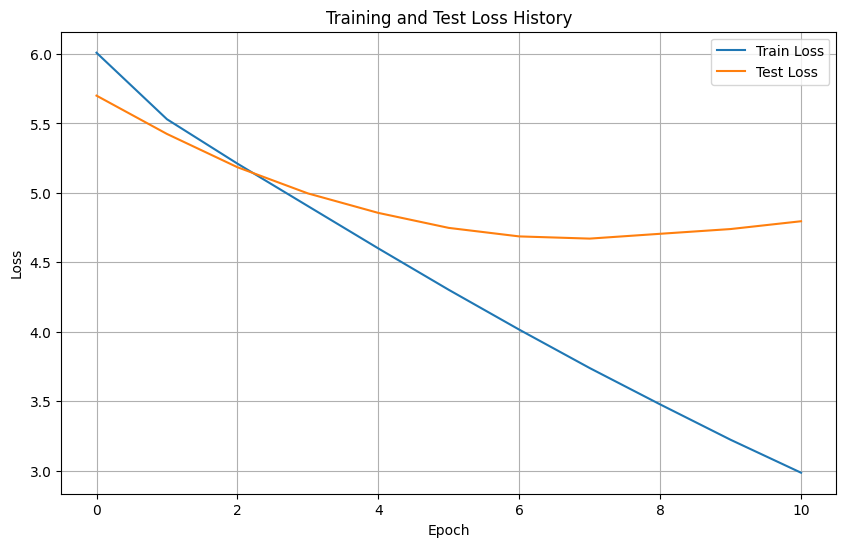

In [ ]:
if len(train_loss_history) > 0 and len(val_loss_history) > 0:
    plt.figure(figsize=(10, 6))
    plt.plot(train_loss_history, label='Train Loss')
    plt.plot(val_loss_history, label='Test Loss')
    plt.title('Training and Test Loss History')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("No loss history to plot.")

### Text Generation Function & Examples

In [ ]:
def generate_text(
    model,
    prompt,
    seq_len=100,
    max_words=150,
    temperature=0.8,
    top_k=20
):
    model.eval()

    generated_words = prompt.lower().split()

    with torch.no_grad():

        for _ in range(max_words):

            # ----------------------------------
            # Encode current text
            # ----------------------------------
            encoded = [
                word2idx.get(word, word2idx["<UNK>"])
                for word in generated_words
            ]

            # Keep only last seq_len tokens
            encoded = encoded[-seq_len:]

            # Left padding if needed
            if len(encoded) < seq_len:
                encoded = (
                    [word2idx["<PAD>"]] * (seq_len - len(encoded))
                    + encoded
                )

            x = torch.tensor(
                encoded,
                dtype=torch.long
            ).unsqueeze(0).to(device)

            # ----------------------------------
            # Model Prediction
            # ----------------------------------
            logits = model(x)

            # Never generate PAD or UNK
            logits[:, word2idx["<PAD>"]] = -float("inf")
            logits[:, word2idx["<UNK>"]] = -float("inf")

            # Temperature Scaling
            logits = logits / temperature

            # ----------------------------------
            # Top-K Sampling
            # ----------------------------------
            top_values, top_indices = torch.topk(
                logits,
                k=top_k,
                dim=-1
            )

            probs = F.softmax(
                top_values,
                dim=-1
            )

            sampled_position = torch.multinomial(
                probs.squeeze(),
                num_samples=1
            )

            next_token = (
                top_indices.squeeze()[sampled_position]
                .item()
            )

            next_word = idx2word[next_token]

            generated_words.append(next_word)

    return " ".join(generated_words)

In [ ]:
# Test 1:
lyrics_1 = generate_text(
    model=model,
    prompt="i am",
    seq_len=50,
    max_words=140,
    temperature=0.8
)

print(lyrics_1)

# Test 2
lyrics_2 = generate_text(
    model=model,
    prompt="you better",
    seq_len=20,
    max_words=40,
    temperature=1.2
)

print(lyrics_2)

# Test 3
lyrics_3 = generate_text(
    model=model,
    prompt="love is",
    temperature=0.5,
)

print(lyrics_3)

i am no matter oh shit it's too mainstream and it's cold it's ridiculous he says but i'm going for that static that i was done with all i just do is murder hands through my head so i didn't feel so much more as a white life you can get ourselves off of this bitch and i got a breath and a sexy father i'ma make a whole damn life and i can't figure out which spice eminem i want to make a new wallet like a fat butt and make the beat down and turn off and make 'em all i do is number the way that i do is number time that you did i never want i think of a girl and i don't really got shit in my eyes but what would you do how to do
you better run your whole ass in the door of me fuck all that was a girl all this shit is mine and i ain't gon' let 'em like that i won't do for her i just want it just stuck on
love is it out it get up go to get a little bit and i'm a man and a laugh like a punch at your neck and hit your ass and i don't know what to do this and i'll be livin' at me and let me bust 

### Save Model Checkpoint

In [ ]:
checkpoint = {
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),

    "word_size": word_size,
    "embed_dim": 128,
    "hidden_dim": 512,
    "num_layers": 3,
    "dropout_prob": 0.2,

    "word2idx": word2idx,
    "idx2word": idx2word,

    "best_val_loss": min(val_loss_history)
}

print(f"Number of parameters: {sum(p.numel() for p in model.parameters())}")

torch.save(
    checkpoint,
    "lyrics_lstm_checkpoint.pth"
)

Number of parameters: 8710133
